In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [61]:
df = pd.read_csv("../../Datasets/mnist-digit-recognizer.csv")
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
3028,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25823,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36491,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18244,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31641,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


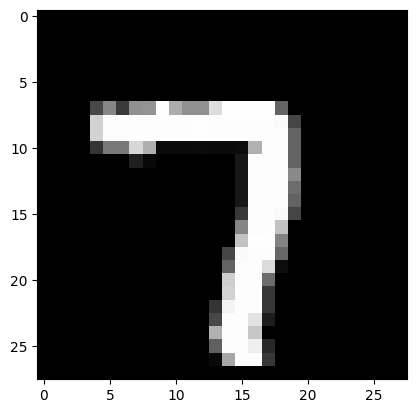

In [62]:
plt.imshow(df.iloc[33470, 1:].values.reshape(28, 28), cmap="gray")

In [63]:
x = df.drop("label", axis=1).values
y = df["label"].values

In [64]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [65]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [66]:
import time

start_time = time.time()
y_pred = knn.predict(x_test)
print("Time taken for prediction:", time.time() - start_time)

Time taken for prediction: 14.637919425964355


In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9648809523809524


## **Applying PCA**

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)    # Retain 95% of the variance , so some features will be dropped

x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [70]:
x_train_trf.shape, x_test_trf.shape

((33600, 315), (8400, 315))

In [71]:
knn = KNeighborsClassifier()

knn.fit(x_train_trf, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [72]:
y_pred = knn.predict(x_test_trf)

In [73]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9463095238095238


In [ ]:
accuracies = []

for i in range(1, x_train.shape[1] + 1):
    pca = PCA(n_components=i)
    x_train_trf = pca.fit_transform(x_train)
    x_test_trf = pca.transform(x_test)

    knn = KNeighborsClassifier()
    knn.fit(x_train_trf, y_train)

    y_pred = knn.predict(x_test_trf)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Components: {i}, Accuracy: {acc:.4f}")

In [90]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [91]:
x_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [92]:
import plotly.express as px

y_train_trf = y_train.astype(str)
fig = px.scatter(x=x_train_trf[:,0],
                 y=x_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [93]:
# transforming in 3D
pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [94]:
x_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [95]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=x_train_trf[:,0], y=x_train_trf[:,1], z=x_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

### **Finding the Optimal Number of Components**

To determine the optimal number of components, we can plot the cumulative explained variance ratio against the number of components. This helps visualize how much variance is captured as we increase the number of components.

''' python
import plotly.express as px
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
fig = px.line(x=range(1, len(cumulative_variance) + 1), y=cumulative_variance, markers=True)
fig.update_layout(
    title="Cumulative Explained Variance Ratio",
    xaxis_title="Number of Components",
    yaxis_title="Cumulative Explained Variance Ratio",
     xaxis=dict(tickmode='linear'),
     yaxis=dict(tickformat='.0%'),
     template='plotly_white',
     width=800,
     height=500,
     paper_bgcolor="LightSteelBlue",
     plot_bgcolor="LightSteelBlue",
        font=dict(size=14, color="DarkBlue"),
)   
'''


**Eigenvalues** represent the amount of variance explained by each principal component. The higher the eigenvalue, the more variance that component captures from the original data. However, eigenvalues are expressed in **absolute terms**, not as percentages.

To convert eigenvalues to **percentage of explained variance**:
```
Variance Ratio (%) = (Eigenvalue / Sum of all Eigenvalues) × 100
```

This normalized approach helps us understand the relative importance of each component. For example, if the first component has an eigenvalue of 100 and the sum of all eigenvalues is 500, then the first component explains 20% of the total variance in the data.

In [96]:
pca.explained_variance_     # Eigen values : amount of variance explained by each component

array([40.67111198, 29.17023401, 26.74459621])

In [106]:
import plotly.express as px
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
fig = px.line(x=range(1, len(cumulative_variance) + 1), y=cumulative_variance, markers=True)
fig.update_layout(
    title="Cumulative Explained Variance Ratio",
    xaxis_title="Number of Components",
    yaxis_title="Cumulative Explained Variance Ratio",
     xaxis=dict(tickmode='linear'),
     yaxis=dict(tickformat='.0%'),
     template='plotly_white',
     width=800,
     height=500,
     paper_bgcolor="LightSteelBlue",
     plot_bgcolor="LightSteelBlue",
        font=dict(size=14, color="DarkBlue"),
)
fig.show()

In [97]:
# Eigen vectors : direction of the components in the original feature space 
pca.components_.shape

(3, 784)

In [98]:
pca.explained_variance_ratio_   # Percentage of variance explained by each component . ex 0.057 is 5.7% variance explained by the first component

array([0.05785192, 0.0414927 , 0.03804239])

In [105]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [85]:
pca.explained_variance_.shape

(784,)

In [86]:
pca.components_.shape

(784, 784)

In [87]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

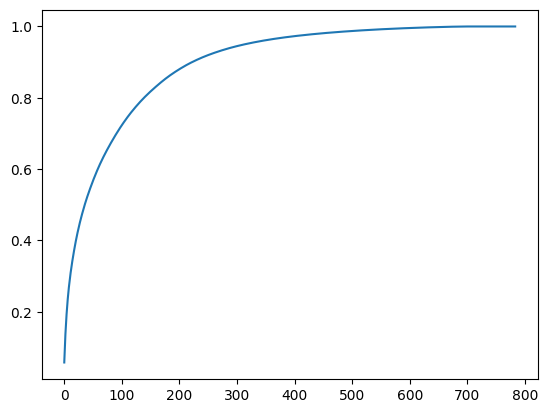

In [88]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

We can observe that we need 200 components to explain 95% of the variance in the data. This is a significant reduction from the original 784 features, demonstrating the power of PCA in dimensionality reduction while retaining most of the information.